# Nine-atom sparse atomistic-edit ptychography

This small, CPU-friendly example reconstructs sparse edits to a known $3\times3$ side-view host. The inverse variables are a smooth host-deformation field, sparse host removals, and generic positive off-grid centres. The known `LatticeSiteModel1D` below is **specimen input to the sparse atomistic-edit method**, not a second reconstruction method.

The synthetic specimen contains one vacancy, one added centre between pixels, and a weak smooth deformation. We deliberately use an Asimov dataset (the exact calibrated Poisson mean) so the example isolates parameterization and optimization from sampling noise. This is an educational numerical example and a transparent internals tutorial, not physical validation or an observability certificate; normal silicon experiments use the compact `ptychography_atomistic_workflow_1d` facade.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from dataclasses import replace
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wide_angle_propagation.propagation_methods import fresnel_propagation_kernel_1d
from wide_angle_propagation.ptychography_1d import (
    LatticeSiteModel1D,
    PtychographyMeasurement1D,
    PtychographyObjective1D,
    ptychography_expected_signal_electrons_1d,
    simulate_glancing_scan_1d,
)
from wide_angle_propagation.ptychography_support_contract_1d import (
    classify_lattice_site_support_1d,
)
from wide_angle_propagation.ptychography_atomistic_edit_1d import (
    AtomisticEditOptions1D,
    atomistic_edit_active_parameter_count_1d,
    atomistic_edit_addition_positions_1d,
    atomistic_edit_state_is_admissible_1d,
    empty_atomistic_edit_state_1d,
    make_atomistic_edit_discovery_support_1d,
    make_atomistic_edit_kernel_1d,
    make_atomistic_edit_model_1d,
    render_atomistic_edit_potential_1d,
    validate_atomistic_edit_state_1d,
)
from wide_angle_propagation.ptychography_atomistic_edit_solver_1d import (
    AtomisticEditSolverOptions1D,
    atomistic_edit_objective_components_1d,
    prepare_atomistic_edit_reconstruction_1d,
    run_prepared_atomistic_edit_reconstruction_1d,
)

print(f"JAX backend: {jax.default_backend()} (x64={jax.config.jax_enable_x64})")

JAX backend: cpu (x64=True)


## 1. Declare the known nine-site host

The compact padded kernel is a transparent synthetic stand-in for a known host-atom potential. In a material study this would be replaced by a certified species-specific template. All nine sites and every patch footprint are bound into a strict support contract. No defect information is used here.

In [2]:
N = 17
shape = (N, N)
s_A = np.arange(N, dtype=np.float64)
u_A = np.arange(N, dtype=np.float64)

site_centres = np.asarray(
    [(s, u) for s in (4, 8, 12) for u in (4, 8, 12)],
    dtype=np.int64,
)
site_coordinates_A = site_centres.astype(np.float64)
patch_starts = site_centres - 2

host_patch = np.zeros((5, 5), dtype=np.float64)
host_patch[1:4, 1:4] = np.asarray(
    [[1.0, 2.0, 1.0], [2.0, 4.0, 2.0], [1.0, 2.0, 1.0]]
)
site_patches = np.broadcast_to(host_patch, (len(site_centres), 5, 5)).copy()
pristine_potential = np.full(shape, 0.02, dtype=np.float64)
for start, patch in zip(patch_starts, site_patches, strict=True):
    pristine_potential[
        start[0] : start[0] + 5, start[1] : start[1] + 5
    ] += patch

host_target_mask = np.zeros(shape, dtype=bool)
host_target_mask[2:15, 2:15] = True
host_support = classify_lattice_site_support_1d(
    site_coordinates_A,
    site_centres,
    patch_starts,
    np.full((len(site_centres), 2), 5, dtype=np.int64),
    host_target_mask,
    np.ones(shape, dtype=bool),
    excluded_probe_power=1e-6,
    atomic_template_cutoff_A=2.0,
    maximum_displacement_A=0.25,
    displacement_control_shape=(2, 2, 2),
    maximum_nuisance_sites=0,
    maximum_specimen_parameters=64,
    strict=True,
)
known_host = LatticeSiteModel1D(
    reference_potential=jnp.asarray(pristine_potential),
    site_coordinates=jnp.asarray(site_coordinates_A),
    site_patches=jnp.asarray(site_patches),
    patch_starts=jnp.asarray(patch_starts),
    control_coordinates_s=jnp.asarray([0.0, 16.0]),
    control_coordinates_u=jnp.asarray([0.0, 16.0]),
    axial_sampling=1.0,
    transverse_sampling=1.0,
    maximum_displacement=0.25,
    metadata={
        "species": "known educational host",
        "source": "declared pristine 3x3 crystal",
    },
    support_contract=host_support,
)

print(f"Known host sites: {len(site_centres)}")
print(f"Host support contract: {host_support.contract_id[:16]}...")

Known host sites: 9
Host support contract: 5131d02ec7f72ca1...


## 2. Add an object-free discovery volume

The discovery mask is chosen from geometry alone: it is a broad beam-accessible rectangle spanning the nine-site host, its interior voids, and nearby surface. Known-host removals use the separate complete host catalogue. The rectangle does not encode whether an added atom exists, how many exist, or where a defect is. The two removal and two addition slots below are compilation capacities, not object labels.

In [3]:
discovery_target_mask = np.zeros(shape, dtype=bool)
discovery_target_mask[3:14, 3:14] = True
discovery_nuisance_mask = np.zeros(shape, dtype=bool)
discovery_support = make_atomistic_edit_discovery_support_1d(
    s_A,
    u_A,
    discovery_target_mask,
    discovery_nuisance_mask,
    surface_envelope_A=(3.0, 13.0),
    geometry_source_id="nine-site-demo-object-free-geometry:v1",
    excluded_probe_power=1e-6,
    metadata={"construction": "declared beam-accessible rectangle"},
)
addition_kernel = make_atomistic_edit_kernel_1d(
    host_patch,
    axial_sampling_A=1.0,
    transverse_sampling_A=1.0,
    host_equivalent_integrated_scattering=float(host_patch.sum()),
    centre_index=(2.0, 2.0),
    parameterization_id="nine-site-demo-known-host-kernel:v1",
    cutoff_A=2.0,
    projection_width_A=5.0,
    metadata={"species": "same as known host"},
)
edit_options = AtomisticEditOptions1D(
    max_host_removals=2,
    max_extra_centres=2,
    max_scattering_equivalent_per_centre=1.5,
    minimum_separation_A=1.5,
    expected_rms_host_strain=0.03,
    edit_penalty_path=(0.105, 0.10),
    discovery_support=discovery_support,
    enable_material_energy_envelope=False,
)
edit_model = make_atomistic_edit_model_1d(
    known_host,
    s_A,
    u_A,
    addition_kernel,
    edit_options,
    metadata={"purpose": "truth-free nine-site inverse model"},
)

model_summary = pd.DataFrame(
    {
        "quantity": [
            "host sites",
            "smooth deformation parameters",
            "removal capacity",
            "addition capacity",
            "discovery pixels",
        ],
        "value": [
            len(site_centres),
            edit_model.deformation_parameter_count,
            edit_options.max_host_removals,
            edit_options.max_extra_centres,
            int(discovery_target_mask.sum()),
        ],
    }
)
print(model_summary.to_string(index=False))

                     quantity  value
                   host sites      9
smooth deformation parameters      8
             removal capacity      2
            addition capacity      2
             discovery pixels    121


## 3. Empty edits are exactly the pristine host

This identity is an important contract check: zero removals, zero additions, and zero displacement must not perturb known material. The active-count convention is $P_\mathrm{deformation}+K_-+3K_+$ in this two-dimensional side view. The eight smooth control components remain fitted parameters even when initialized at zero.

In [4]:
empty_state = empty_atomistic_edit_state_1d(edit_model)
empty_potential = np.asarray(
    render_atomistic_edit_potential_1d(edit_model, empty_state)
)
identity_is_exact = np.array_equal(empty_potential, pristine_potential)
assert identity_is_exact

print(f"Empty-edit identity is exact: {identity_is_exact}")
print(
    "Empty-state active count: ",
    atomistic_edit_active_parameter_count_1d(edit_model, empty_state),
    "= 8 deformation + 0 removal + 3x0 addition",
)

Empty-edit identity is exact: True
Empty-state active count:  8 = 8 deformation + 0 removal + 3x0 addition


## 4. Create private synthetic truth, then cross a counts-only boundary

For simulation only, site 2 at $(4,12)$ is removed, a centre is added in an illuminated interior void at $(6.35,5.75)$, and the four displacement-control vectors define a weak affine-like deformation. The inverse model above is already frozen. Only calibrated detector totals cross into `prepare_atomistic_edit_reconstruction_1d`; neither this state nor its potential or coordinates are accepted by that API.

In [5]:
truth_controls_A = np.asarray(
    [
        [[-0.04, -0.02], [-0.04, 0.03]],
        [[0.04, -0.02], [0.04, 0.03]],
    ],
    dtype=np.float64,
)
private_truth_state = replace(
    empty_state,
    host_removal_indices=jnp.asarray([2, 0], dtype=jnp.int32),
    host_removal_fractions=jnp.asarray([1.0, 0.0]),
    host_removal_active=jnp.asarray([True, False]),
    extra_anchor_indices=jnp.asarray([[6, 6], [3, 3]], dtype=jnp.int32),
    extra_position_offsets_A=jnp.asarray([[0.35, -0.25], [0.0, 0.0]]),
    extra_scattering_equivalents=jnp.asarray([0.80, 0.0]),
    extra_active=jnp.asarray([True, False]),
    host_displacement_controls=jnp.asarray(truth_controls_A),
)
validate_atomistic_edit_state_1d(edit_model, private_truth_state)
truth_is_admissible = atomistic_edit_state_is_admissible_1d(
    edit_model, private_truth_state
)
assert truth_is_admissible
private_truth_potential = np.asarray(
    render_atomistic_edit_potential_1d(edit_model, private_truth_state)
)
private_truth_addition_A = np.asarray(
    atomistic_edit_addition_positions_1d(edit_model, private_truth_state)
)[0]

print(f"Private vacancy site: 2 at {site_coordinates_A[2].tolist()} A")
print(f"Private added centre: {private_truth_addition_A.tolist()} A")
print(f"Private control RMS: {np.sqrt(np.mean(truth_controls_A**2)):.4f} A")
print(f"Private Level-1 state is admissible: {truth_is_admissible}")
print(
    f"Private active count: {atomistic_edit_active_parameter_count_1d(edit_model, private_truth_state)}"
)

Private vacancy site: 2 at [4.0, 12.0] A
Private added centre: [6.35, 5.75] A
Private control RMS: 0.0335 A
Private Level-1 state is admissible: True
Private active count: 12


In [6]:
energy_eV = 30_000.0
slice_thickness_A = 1.0
window_length = 5
transverse_index = jnp.arange(N, dtype=jnp.float64) - 8.0

probe_rows = []
window_starts = []
for start in (0, 2, 4, 6, 8, 10, 12):
    for shift in (-4.0, 0.0, 4.0):
        probe_index = len(probe_rows)
        amplitude = jnp.exp(
            -0.5 * ((transverse_index - shift) / 2.0) ** 2
        )
        phase = jnp.exp(
            1j * (0.08 + 0.01 * probe_index) * transverse_index
        )
        probe_rows.append(amplitude * phase)
        window_starts.append(start)
probe_rows = jnp.stack(probe_rows)
window_starts = jnp.asarray(window_starts, dtype=jnp.int32)
propagation_kernel = fresnel_propagation_kernel_1d(
    N, 1.0, slice_thickness_A, energy_eV
)

private_intensities = simulate_glancing_scan_1d(
    jnp.asarray(private_truth_potential),
    probe_rows,
    window_starts,
    window_length,
    propagation_kernel,
    slice_thickness_A,
    energy_eV,
    rematerialize=False,
)
count_objective = PtychographyObjective1D(
    kind="poisson_deviance",
    electrons_per_pattern=500_000.0,
    minimum_expected_electrons=1e-9,
)
poisson_mean_electrons = ptychography_expected_signal_electrons_1d(
    private_intensities, probe_rows, count_objective
)
measurement = PtychographyMeasurement1D(
    calibrated_signal_electrons=poisson_mean_electrons,
    observed_total_electrons=poisson_mean_electrons,
    valid_mask=jnp.ones_like(poisson_mean_electrons, dtype=bool),
    calibrated_dark_electrons_per_pixel=jnp.zeros_like(poisson_mean_electrons),
    calibrated_read_noise_std_electrons=jnp.zeros_like(poisson_mean_electrons),
    calibration_id="nine-site-demo-Asimov-Poisson:v1",
    metadata={
        "source": "calibrated detector totals only",
        "sampling": "Asimov Poisson mean; no random draw",
    },
)

# Reconstruction boundary: only the frozen model, acquisition, calibrated
# counts, count objective, and held-out scan indices are passed.
prepared = prepare_atomistic_edit_reconstruction_1d(
    edit_model,
    probe_rows,
    window_starts,
    window_length,
    propagation_kernel,
    slice_thickness_A,
    energy_eV,
    measurement,
    count_objective,
    validation_indices=[4, 10, 16],
    audit_indices=[20],
)
boundary_is_truth_free = (
    prepared.metadata["truth_inputs_accepted"] is False
    and prepared.model.metadata == {"purpose": "truth-free nine-site inverse model"}
)
assert boundary_is_truth_free
print(f"Reconstruction boundary is truth-free: {boundary_is_truth_free}")
print(
    f"Scans: {len(window_starts)} = {len(prepared.training_indices)} train + "
    f"{len(prepared.validation_indices)} validation + {len(prepared.audit_indices)} audit"
)

Reconstruction boundary is truth-free: True
Scans: 21 = 17 train + 3 validation + 1 audit


## 5. Inspect every objective term

The reported objective is the calibrated count deviance plus the edit-mass penalty and the weak Level-1 elastic and hard-core terms. The private truth is evaluated here only as a post-boundary diagnostic; it is not an optimizer input.

In [7]:
objective_fields = (
    "count_deviance",
    "edit_mass",
    "weighted_edit_penalty",
    "elastic_penalty",
    "hard_core_penalty",
    "total_objective",
)

def objective_row(label, state, edit_penalty):
    components = atomistic_edit_objective_components_1d(
        prepared,
        state,
        edit_penalty,
        ablation="level1_physical",
    )
    return {
        "state": label,
        **{name: float(np.asarray(getattr(components, name))) for name in objective_fields},
    }

diagnostic_objectives = pd.DataFrame(
    [
        objective_row("empty initialization", empty_state, 0.10),
        objective_row("private truth (diagnostic only)", private_truth_state, 0.10),
    ]
)
print(diagnostic_objectives.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

                          state  count_deviance  edit_mass  weighted_edit_penalty  elastic_penalty  hard_core_penalty  total_objective
           empty initialization        0.232935          0                      0                0                  0         0.232935
private truth (diagnostic only)               0        1.8                   0.18       0.00643808                  0         0.186438


## 6. Run the tiny active-set reconstruction

TQDM reports active-set progress across the fixed decreasing penalty path. Held-out validation chooses the path point; the audit scan is evaluated only afterward. The KKT certificate is explicitly limited to the declared proposal grid.

In [8]:
solver_options = AtomisticEditSolverOptions1D(
    ablation="level1_physical",
    maximum_active_set_iterations=5,
    joint_refinement_updates=30,
    polish_updates=45,
    debias_updates=200,
    learning_rate=0.03,
    polish_learning_rate=0.01,
    debias_learning_rate=0.01,
    gradient_clip=1.0,
    birth_removal_fraction=0.20,
    birth_scattering_equivalent=0.20,
    pruning_threshold=1e-3,
    proposal_grid_kkt_tolerance=2e-4,
    active_projected_gradient_tolerance=1e-2,
    debias_projected_gradient_tolerance=1e-2,
    validation_relative_tolerance=0.05,
    validation_absolute_tolerance=1e-8,
    seed=0,
)

started = time.perf_counter()
result = run_prepared_atomistic_edit_reconstruction_1d(
    prepared,
    options=solver_options,
    show_progress=True,
    evaluate_audit=True,
)
reconstruction_runtime_s = time.perf_counter() - started
assert result.metadata["truth_inputs_used"] is False
assert result.prepared_problem_id == prepared.reconstruction_problem_id

print(
    f"RESULT converged={result.converged}; stop={result.stop_reason}; "
    f"runtime={reconstruction_runtime_s:.2f} s"
)
print(
    f"Selected lambda={result.selected_edit_penalty:g}; "
    f"active parameters={result.active_parameter_count}; "
    f"validation deviance={result.debiased_validation_count_deviance:.6g}; "
    f"audit deviance={result.debiased_audit_count_deviance:.6g}"
)
print(
    f"Proposal-grid KKT={result.selected_kkt.satisfied}; "
    f"debias converged={result.debias_converged} "
    f"(norm={result.debias_projected_gradient_norm:.3g} <= "
    f"{result.debias_projected_gradient_tolerance:.3g}); "
    f"capacity exhausted={result.capacity_exhausted}"
)

RESULT converged=True; stop=frozen_path_solved_and_validation_selected; runtime=19.94 s
Selected lambda=0.1; active parameters=12; validation deviance=0.00277696; audit deviance=0.000175394
Proposal-grid KKT=True; debias converged=True (norm=0.000696 <= 0.01); capacity exhausted=False


AE-2 lambda=0.1 iteration=1:  40%|####      | 4/10 [00:15<00:22,  3.83s/active-set step, active=0.00392, dormant=-0.0193, event=grid-kkt]


## 7. Read the sparse result and compare with private truth

The active count is compact and auditable. Recovery quality is deliberately reported without hiding the limitations of this tiny acquisition: the vacancy is well recovered, while the added-centre position/mass and weak deformation remain approximate.

In [9]:
recovered_state = result.debiased_state
recovered_removal_active = np.asarray(recovered_state.host_removal_active, dtype=bool)
recovered_removal_indices = np.asarray(recovered_state.host_removal_indices, dtype=int)
recovered_removal_fractions = np.asarray(recovered_state.host_removal_fractions, dtype=float)
recovered_addition_active = np.asarray(recovered_state.extra_active, dtype=bool)
recovered_addition_positions_A = np.asarray(
    atomistic_edit_addition_positions_1d(edit_model, recovered_state)
)
recovered_addition_mass = np.asarray(
    recovered_state.extra_scattering_equivalents, dtype=float
)
active_removal_slot = int(np.flatnonzero(recovered_removal_active)[0])
active_addition_slot = int(np.flatnonzero(recovered_addition_active)[0])
recovered_vacancy_site = recovered_removal_indices[active_removal_slot]
recovered_vacancy_fraction = recovered_removal_fractions[active_removal_slot]
recovered_addition_A = recovered_addition_positions_A[active_addition_slot]
recovered_mass = recovered_addition_mass[active_addition_slot]
addition_position_error_A = float(
    np.linalg.norm(recovered_addition_A - private_truth_addition_A)
)
control_rmse_A = float(
    np.sqrt(
        np.mean(
            (np.asarray(recovered_state.host_displacement_controls) - truth_controls_A) ** 2
        )
    )
)

parameter_comparison = pd.DataFrame(
    [
        {
            "quantity": "vacancy site",
            "truth": "2",
            "recovered": str(recovered_vacancy_site),
            "absolute error": float(recovered_vacancy_site != 2),
        },
        {
            "quantity": "vacancy fraction",
            "truth": "1.000",
            "recovered": f"{recovered_vacancy_fraction:.3f}",
            "absolute error": abs(recovered_vacancy_fraction - 1.0),
        },
        {
            "quantity": "addition position (s,u) A",
            "truth": np.array2string(private_truth_addition_A, precision=3),
            "recovered": np.array2string(recovered_addition_A, precision=3),
            "absolute error": addition_position_error_A,
        },
        {
            "quantity": "host-equivalent addition mass",
            "truth": "0.800",
            "recovered": f"{recovered_mass:.3f}",
            "absolute error": abs(recovered_mass - 0.8),
        },
        {
            "quantity": "control-field RMSE A",
            "truth": "0.000",
            "recovered": f"{control_rmse_A:.4f}",
            "absolute error": control_rmse_A,
        },
    ]
)
print(parameter_comparison.to_string(index=False))
active_removal_count = int(
    np.count_nonzero(
        recovered_removal_active & (recovered_removal_fractions > 0.0)
    )
)
active_addition_count = int(
    np.count_nonzero(
        recovered_addition_active & (recovered_addition_mass > 0.0)
    )
)
derived_active_count = (
    edit_model.deformation_parameter_count
    + active_removal_count
    + 3 * active_addition_count
)
assert derived_active_count == atomistic_edit_active_parameter_count_1d(
    edit_model, recovered_state
)
print(
    f"Active-count check: {derived_active_count} = "
    f"{edit_model.deformation_parameter_count} deformation + "
    f"{active_removal_count} removal + 3x{active_addition_count} addition"
)

                     quantity       truth     recovered  absolute error
                 vacancy site           2             2        0.000000
             vacancy fraction       1.000         0.992        0.008256
    addition position (s,u) A [6.35 5.75] [6.348 5.998]        0.248340
host-equivalent addition mass       0.800         0.720        0.080339
         control-field RMSE A       0.000        0.0619        0.061925
Active-count check: 12 = 8 deformation + 1 removal + 3x1 addition


In [10]:
recovered_objectives = pd.DataFrame(
    [
        objective_row(
            "selected penalized state",
            result.penalized_state,
            result.selected_edit_penalty,
        ),
        objective_row("fixed-support debiased state", recovered_state, 0.0),
    ]
)
print(recovered_objectives.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

                       state  count_deviance  edit_mass  weighted_edit_penalty  elastic_penalty  hard_core_penalty  total_objective
    selected penalized state       0.0523647   0.671171              0.0671171      0.000460622                  0         0.119942
fixed-support debiased state      0.00187879    1.71141                      0      9.12899e-07                  0        0.0018797


## 8. TARGET-only recovered-versus-truth view

The axes are cropped to the authenticated union of TARGET host influence and TARGET addition influence; masked pixels, if present inside that crop, are white. Nothing outside the selected mutable/reportable region is presented as a reconstructed specimen.

TARGET-only displayed pixels: 225 / 289


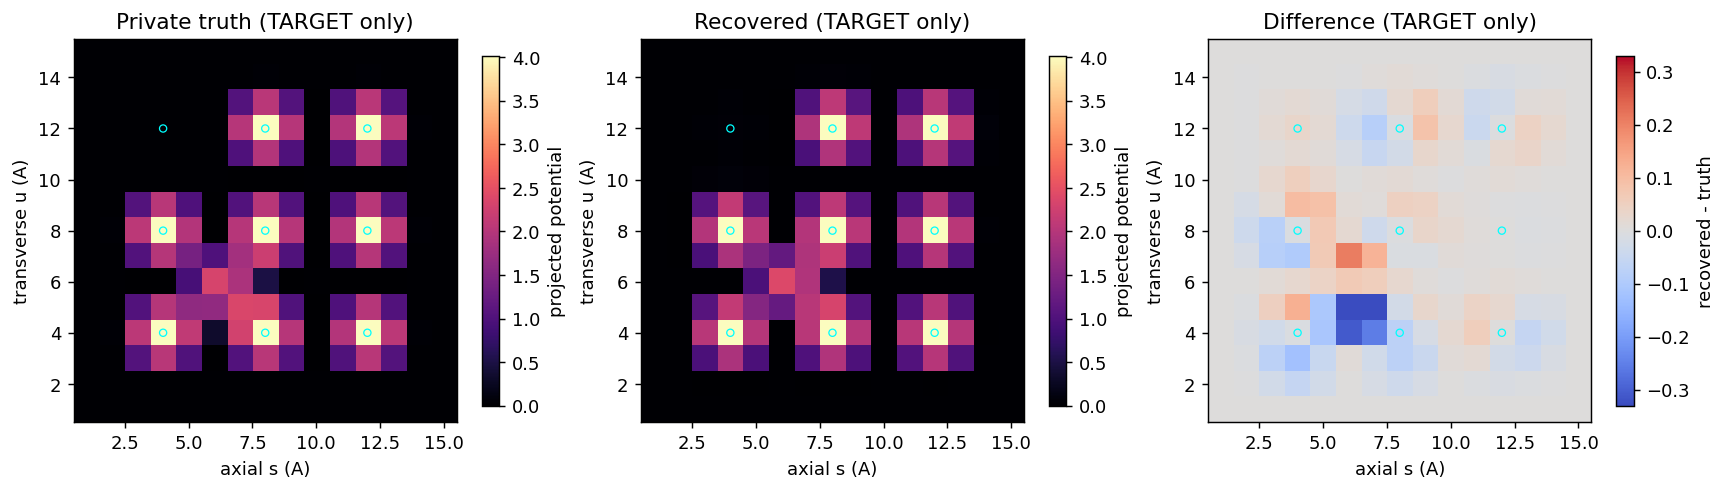

In [11]:
target_view_mask = (
    np.asarray(edit_model.host_model.support_contract.target_influence_mask, dtype=bool)
    | np.asarray(edit_model.support_contract.addition_influence_mask, dtype=bool)
)
assert not np.any(discovery_nuisance_mask)
assert np.all(target_view_mask <= np.asarray(edit_model.support_contract.total_influence_mask))
recovered_potential = np.asarray(
    render_atomistic_edit_potential_1d(edit_model, recovered_state)
)
truth_target_view = np.where(target_view_mask, private_truth_potential, np.nan)
recovered_target_view = np.where(target_view_mask, recovered_potential, np.nan)
difference_target_view = np.where(
    target_view_mask, recovered_potential - private_truth_potential, np.nan
)

finite_joint = np.concatenate(
    [
        truth_target_view[np.isfinite(truth_target_view)],
        recovered_target_view[np.isfinite(recovered_target_view)],
    ]
)
potential_vmax = float(np.percentile(finite_joint, 99.5))
difference_limit = max(
    float(np.percentile(np.abs(difference_target_view[np.isfinite(difference_target_view)]), 99.5)),
    1e-9,
)
selected_rows, selected_columns = np.where(target_view_mask)
plot_extent = [s_A[0] - 0.5, s_A[-1] + 0.5, u_A[0] - 0.5, u_A[-1] + 0.5]
view_limits = (
    s_A[selected_rows.min()] - 0.5,
    s_A[selected_rows.max()] + 0.5,
    u_A[selected_columns.min()] - 0.5,
    u_A[selected_columns.max()] + 0.5,
)

magma = plt.get_cmap("magma").copy()
magma.set_bad("white")
coolwarm = plt.get_cmap("coolwarm").copy()
coolwarm.set_bad("white")
figure, axes = plt.subplots(1, 3, figsize=(13.2, 3.8), constrained_layout=True)
for axis, values, title in zip(
    axes[:2],
    (truth_target_view, recovered_target_view),
    ("Private truth (TARGET only)", "Recovered (TARGET only)"),
):
    image = axis.imshow(
        values.T,
        origin="lower",
        extent=plot_extent,
        cmap=magma,
        vmin=0.0,
        vmax=potential_vmax,
        aspect="equal",
    )
    figure.colorbar(image, ax=axis, shrink=0.8, label="projected potential")
    axis.set_title(title)
difference_image = axes[2].imshow(
    difference_target_view.T,
    origin="lower",
    extent=plot_extent,
    cmap=coolwarm,
    vmin=-difference_limit,
    vmax=difference_limit,
    aspect="equal",
)
figure.colorbar(
    difference_image, ax=axes[2], shrink=0.8, label="recovered - truth"
)
axes[2].set_title("Difference (TARGET only)")
for axis in axes:
    axis.scatter(
        site_coordinates_A[:, 0],
        site_coordinates_A[:, 1],
        s=16,
        facecolors="none",
        edgecolors="cyan",
        linewidths=0.7,
    )
    axis.set(
        xlabel="axial s (A)",
        ylabel="transverse u (A)",
        xlim=view_limits[:2],
        ylim=view_limits[2:],
    )
plt.show()
print(f"TARGET-only displayed pixels: {int(target_view_mask.sum())} / {target_view_mask.size}")

## What this example establishes—and what it does not

The public sparse atomistic-edit path exactly preserves the empty known host, keeps object truth outside preparation and optimization, reports every objective component, and converges here to the correct vacancy plus one approximate off-grid centre using 12 active specimen parameters. The weak deformation is only partially constrained, and the added-centre localization and mass are not exact. A real claim would still require Poisson draws, nuisance fitting, multistart stability, observability/depth analysis, archive replay, realistic species-specific kernels, and blind held-out benchmarks.